In [3]:
from google.colab import drive
drive.mount('/content/drive')
from tensorflow.keras.models import load_model


Mounted at /content/drive


In [4]:
eff_model = load_model("/content/drive/MyDrive/Modelsforcomparison/EfficientNet-B0.keras")
vgg_model = load_model("/content/drive/MyDrive/Modelsforcomparison/vgg16.keras")
res_model = load_model("/content/drive/MyDrive/Modelsforcomparison/ResNet-50.keras")
desnet = load_model("/content/drive/MyDrive/Modelsforcomparison/DenseNet-121.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, roc_curve, auc
)
from matplotlib.backends.backend_pdf import PdfPages
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ULTRA-CLEAR VISUAL STYLE SETUP (Optimized for MS Word)
# ============================================================
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 150,  # High resolution setup for crisp screenshots
})

# 4 Distinct Professional Colors for your 4 Models
COLORS = ['#1e40af', '#16a34a', '#dc2626', '#6d28d9']

In [6]:
# ============================================================
# 1. TEST DIRECTORY PATH
# ============================================================
TEST_DIR = "/content/drive/MyDrive/tumor/tumor/Testing"

# ============================================================
# 2. DATA GENERATOR INITIALIZATION
# ============================================================
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print(f"\n✅ Classes Found  : {class_names}")
print(f"✅ Total Samples  : {test_generator.samples}\n")

# ============================================================
# 3. VERIFIED MODELS STRUCTURING
# ============================================================
# Ensuring all 4 model variables are currently defined in your session
models_list      = [vgg_model, res_model, eff_model, desnet]
model_names_list = ["VGG16", "ResNet50", "EfficientNetB0", "DenseNet121"]


Found 1311 images belonging to 4 classes.

✅ Classes Found  : ['glioma', 'meningioma', 'notumor', 'pituitary']
✅ Total Samples  : 1311



In [7]:
# ============================================================
# 4. EVALUATE SINGLE MODEL
# ============================================================
def evaluate_single_model(model, test_generator, model_name, class_names):
    print(f"\n" + "═"*70)
    print(f" 🔍 CRITICAL EVALUATION STARTED FOR: {model_name.upper()}")
    print("═"*70)

    # Reset generator to prevent index misalignment
    test_generator.reset()
    y_true = test_generator.classes

    # Track precise processing speed
    start = time.time()
    preds_probs = model.predict(test_generator, verbose=1)
    elapsed = (time.time() - start) / len(y_true) * 1000

    y_pred   = np.argmax(preds_probs, axis=1)
    accuracy = np.mean(y_pred == y_true)

    # Extract dynamic classification statistics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(len(class_names))
    )
    w_prec, w_rec, w_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    cm     = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    # Cleaned up summary log (looks sharp in screenshots)
    print(f"\n📊 OVERALL METRICS SUMMARY ({model_name}):")
    print(f" ├─ Accuracy       : {accuracy:.4f}  ({accuracy:.2%})")
    print(f" ├─ Weighted F1    : {w_f1:.4f}  ({w_f1:.2%})")
    print(f" └─ Inference Time : {elapsed:.2f} ms/image")

    print(f"\n🎯 CLASS-WISE DETAILED METRICS:")
    print(f" ┌{'─'*18}┬{'─'*13}┬{'─'*13}┬{'─'*13}┬{'─'*11}┐")
    print(f" │ {'Class Name':<16} │ {'Precision':^11} │ {'Recall':^11} │ {'F1-Score':^11} │ {'Support':^9} │")
    print(f" ├{'─'*18}┼{'─'*13}┼{'─'*13}┼{'─'*13}┼{'─'*11}┤")

    for i, name in enumerate(class_names):
        print(f" │ {name:<16} │ {precision[i]:^11.4f} │ {recall[i]:^11.4f} │ {f1[i]:^11.4f} │ {int(support[i]):^9} │")

    print(f" └{'─'*18}┴{'─'*13}┴{'─'*13}┴{'─'*13}┴{'─'*11}┘")

    # Pack everything cleanly into data structural arrays
    return {
        'model_name'           : model_name,
        'accuracy'             : accuracy,
        'precision'            : w_prec,
        'recall'               : w_rec,
        'f1'                   : w_f1,
        'inference_time'       : elapsed,
        'per_class_precision'  : dict(zip(class_names, precision)),
        'per_class_recall'     : dict(zip(class_names, recall)),
        'per_class_f1'         : dict(zip(class_names, f1)),
        'per_class_support'    : dict(zip(class_names, support)),
        'confusion_matrix'     : cm,
        'classification_report': report,
        'preds_probs'          : preds_probs,
        'y_true'               : y_true,
        'y_pred'               : y_pred,
    }

In [8]:
# ============================================================
# 5. PLOT: CONFUSION MATRICES (2x2 Grid Layout — Crystal Clear)
# ============================================================
def plot_confusion_matrices(all_results, class_names):
    # 2 Rows and 2 Columns to accommodate exactly 4 models without crowding
    fig, axes = plt.subplots(2, 2, figsize=(15, 13))
    fig.suptitle('Confusion Matrices Matrix Analysis — All Models', fontsize=18, fontweight='bold', y=1.02)

    # Flattening axes array to seamlessly loop from index 0 to 3
    axes_flat = axes.flatten()

    for i, res in enumerate(all_results):
        ax = axes_flat[i]

        # Calculate percentage normalization safely
        cm_norm = res['confusion_matrix'].astype(float)
        cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True)

        # Generating big-block heatmap matrices
        sns.heatmap(
            cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=1.2, vmin=0, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'}, cbar=True
        )

        # Overlaying raw counts (n=value) with high contrast alignment
        for r in range(len(class_names)):
            for c in range(len(class_names)):
                count = res['confusion_matrix'][r, c]
                # Shift position to prevent text collisions inside squares
                ax.text(c + 0.5, r + 0.76, f'(n={count})',
                        ha='center', va='center', fontsize=10, color='#2d3748', fontweight='medium')

        # Individual subplot properties
        ax.set_title(
            f"{res['model_name']}\nAccuracy: {res['accuracy']:.2%}  |  Weighted F1: {res['f1']:.4f}",
            fontsize=13, fontweight='bold', pad=10
        )
        ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=6)
        ax.set_ylabel('True Label', fontsize=11, fontweight='bold', labelpad=6)

        # Rotating tags to avoid clipping errors in Word layouts
        ax.tick_params(axis='x', rotation=20, labelsize=10)
        ax.tick_params(axis='y', rotation=0, labelsize=10)

    plt.tight_layout()
    # High-density DPI export for publication grade document resolution
    plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=200)
    plt.show()
    print("✅ Successfully Saved: confusion_matrices.png (Optimized 2x2 Layout)")


███████████████████████████████████████████████████████████████████████████
 🧠  SYSTEM PIPELINE DIAGNOSTIC: INTER-MODEL BENCHMARKING OPERATIONS
███████████████████████████████████████████████████████████████████████████

══════════════════════════════════════════════════════════════════════
 🔍 CRITICAL EVALUATION STARTED FOR: VGG16
══════════════════════════════════════════════════════════════════════
41/41 ━━━━━━━━━━━━━━━━━━━━ 822s 20s/step

📊 OVERALL METRICS SUMMARY (VGG16):
 ├─ Accuracy       : 0.9878  (98.78%)
 ├─ Weighted F1    : 0.9878  (98.78%)
 └─ Inference Time : 645.70 ms/image

🎯 CLASS-WISE DETAILED METRICS:
 ┌──────────────────┬─────────────┬─────────────┬─────────────┬───────────┐
 │ Class Name       │  Precision  │   Recall    │  F1-Score   │  Support  │
 ├──────────────────┼─────────────┼─────────────┼─────────────┼───────────┤
 │ glioma           │   0.9865    │   0.9767    │   0.9816    │    300    │
 │ meningioma       │   0.9742    │   0.9869    │   0.9805    │    3

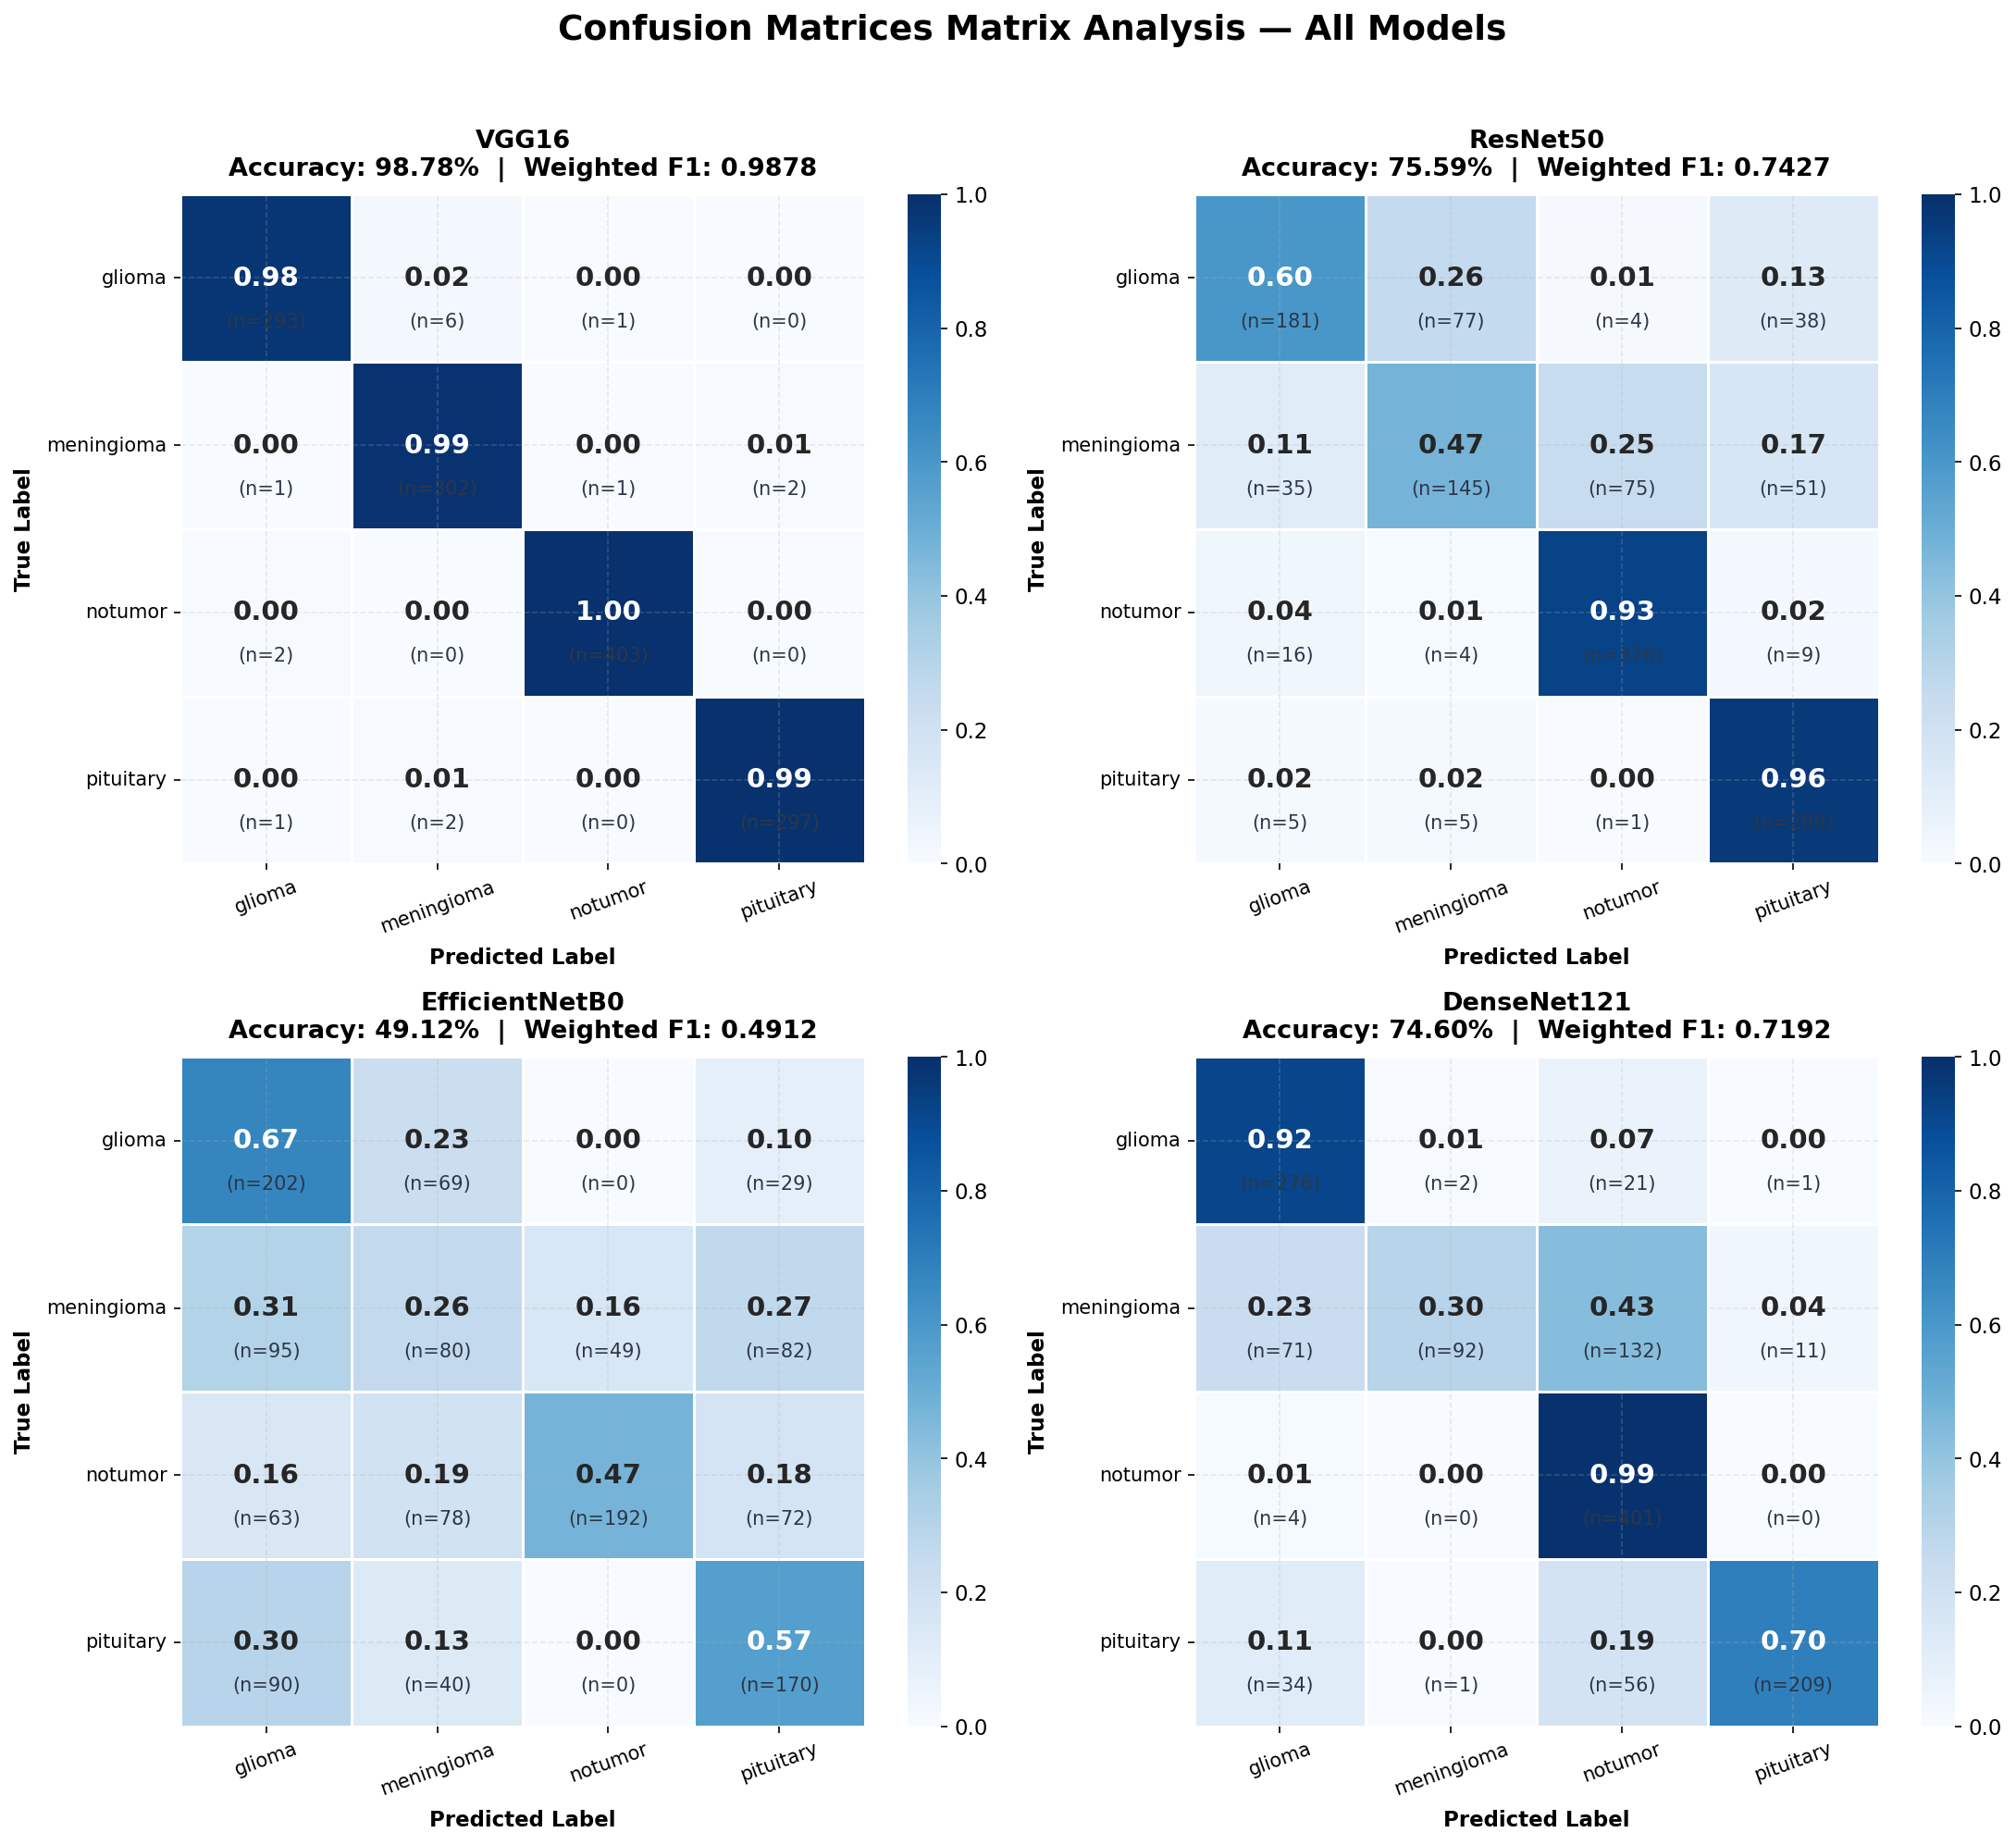

✅ Successfully Saved: confusion_matrices.png (Optimized 2x2 Layout)


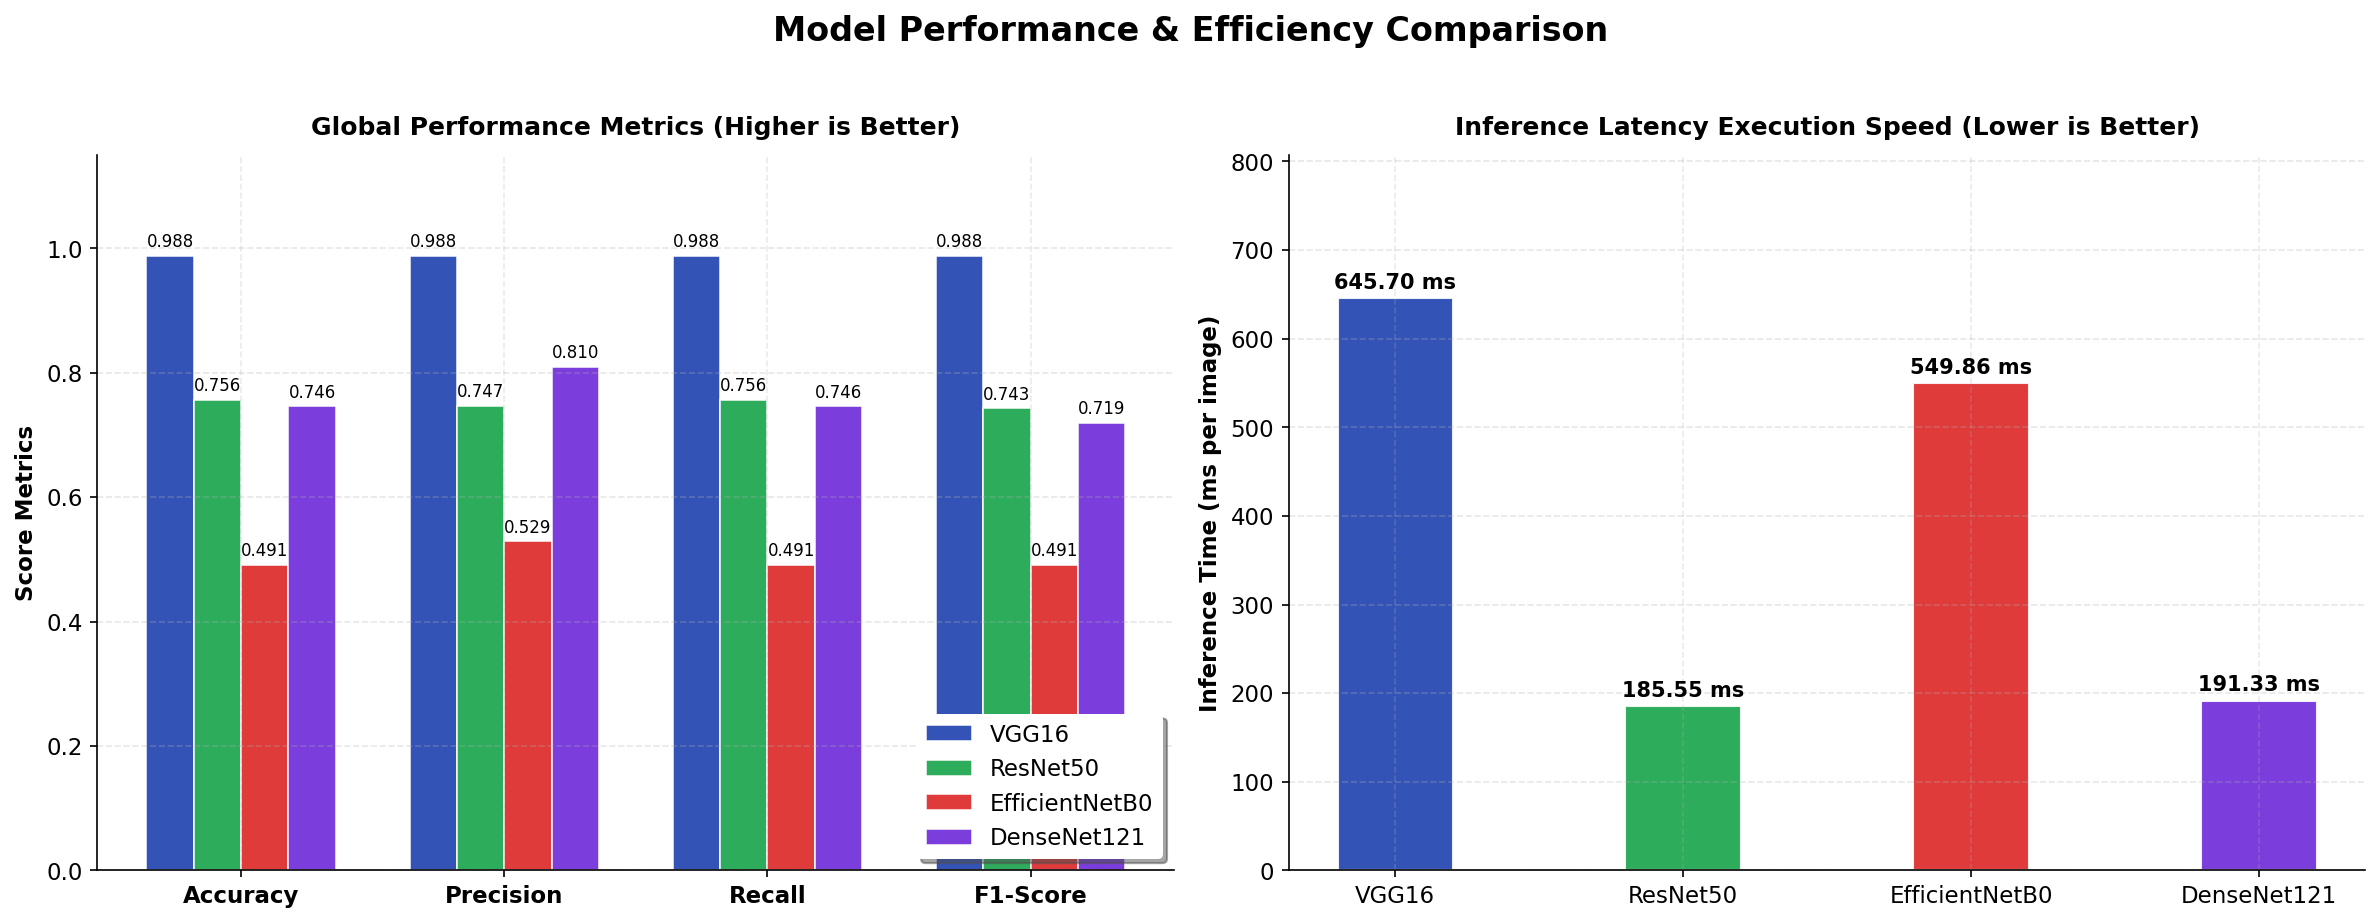

✅ Saved: metrics_comparison.png


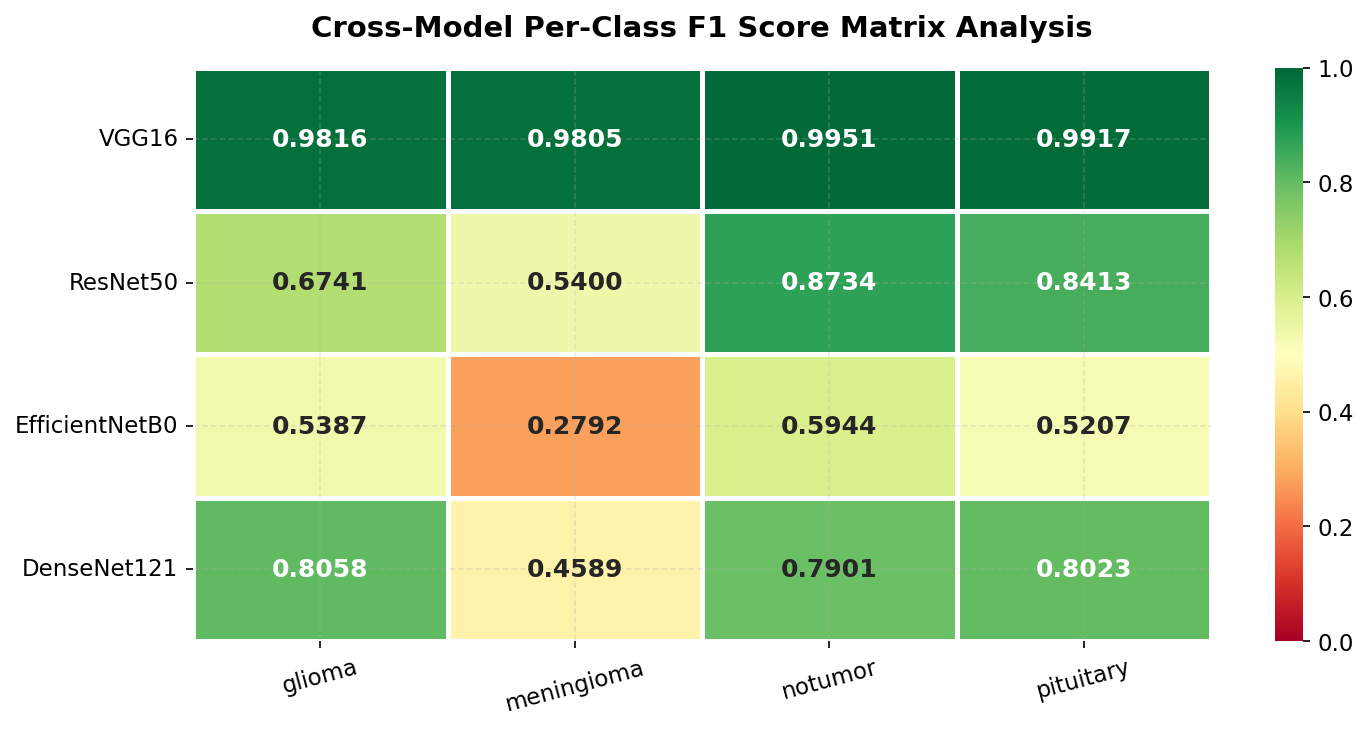

✅ Saved: perclass_f1.png (Consolidated Matrix View)


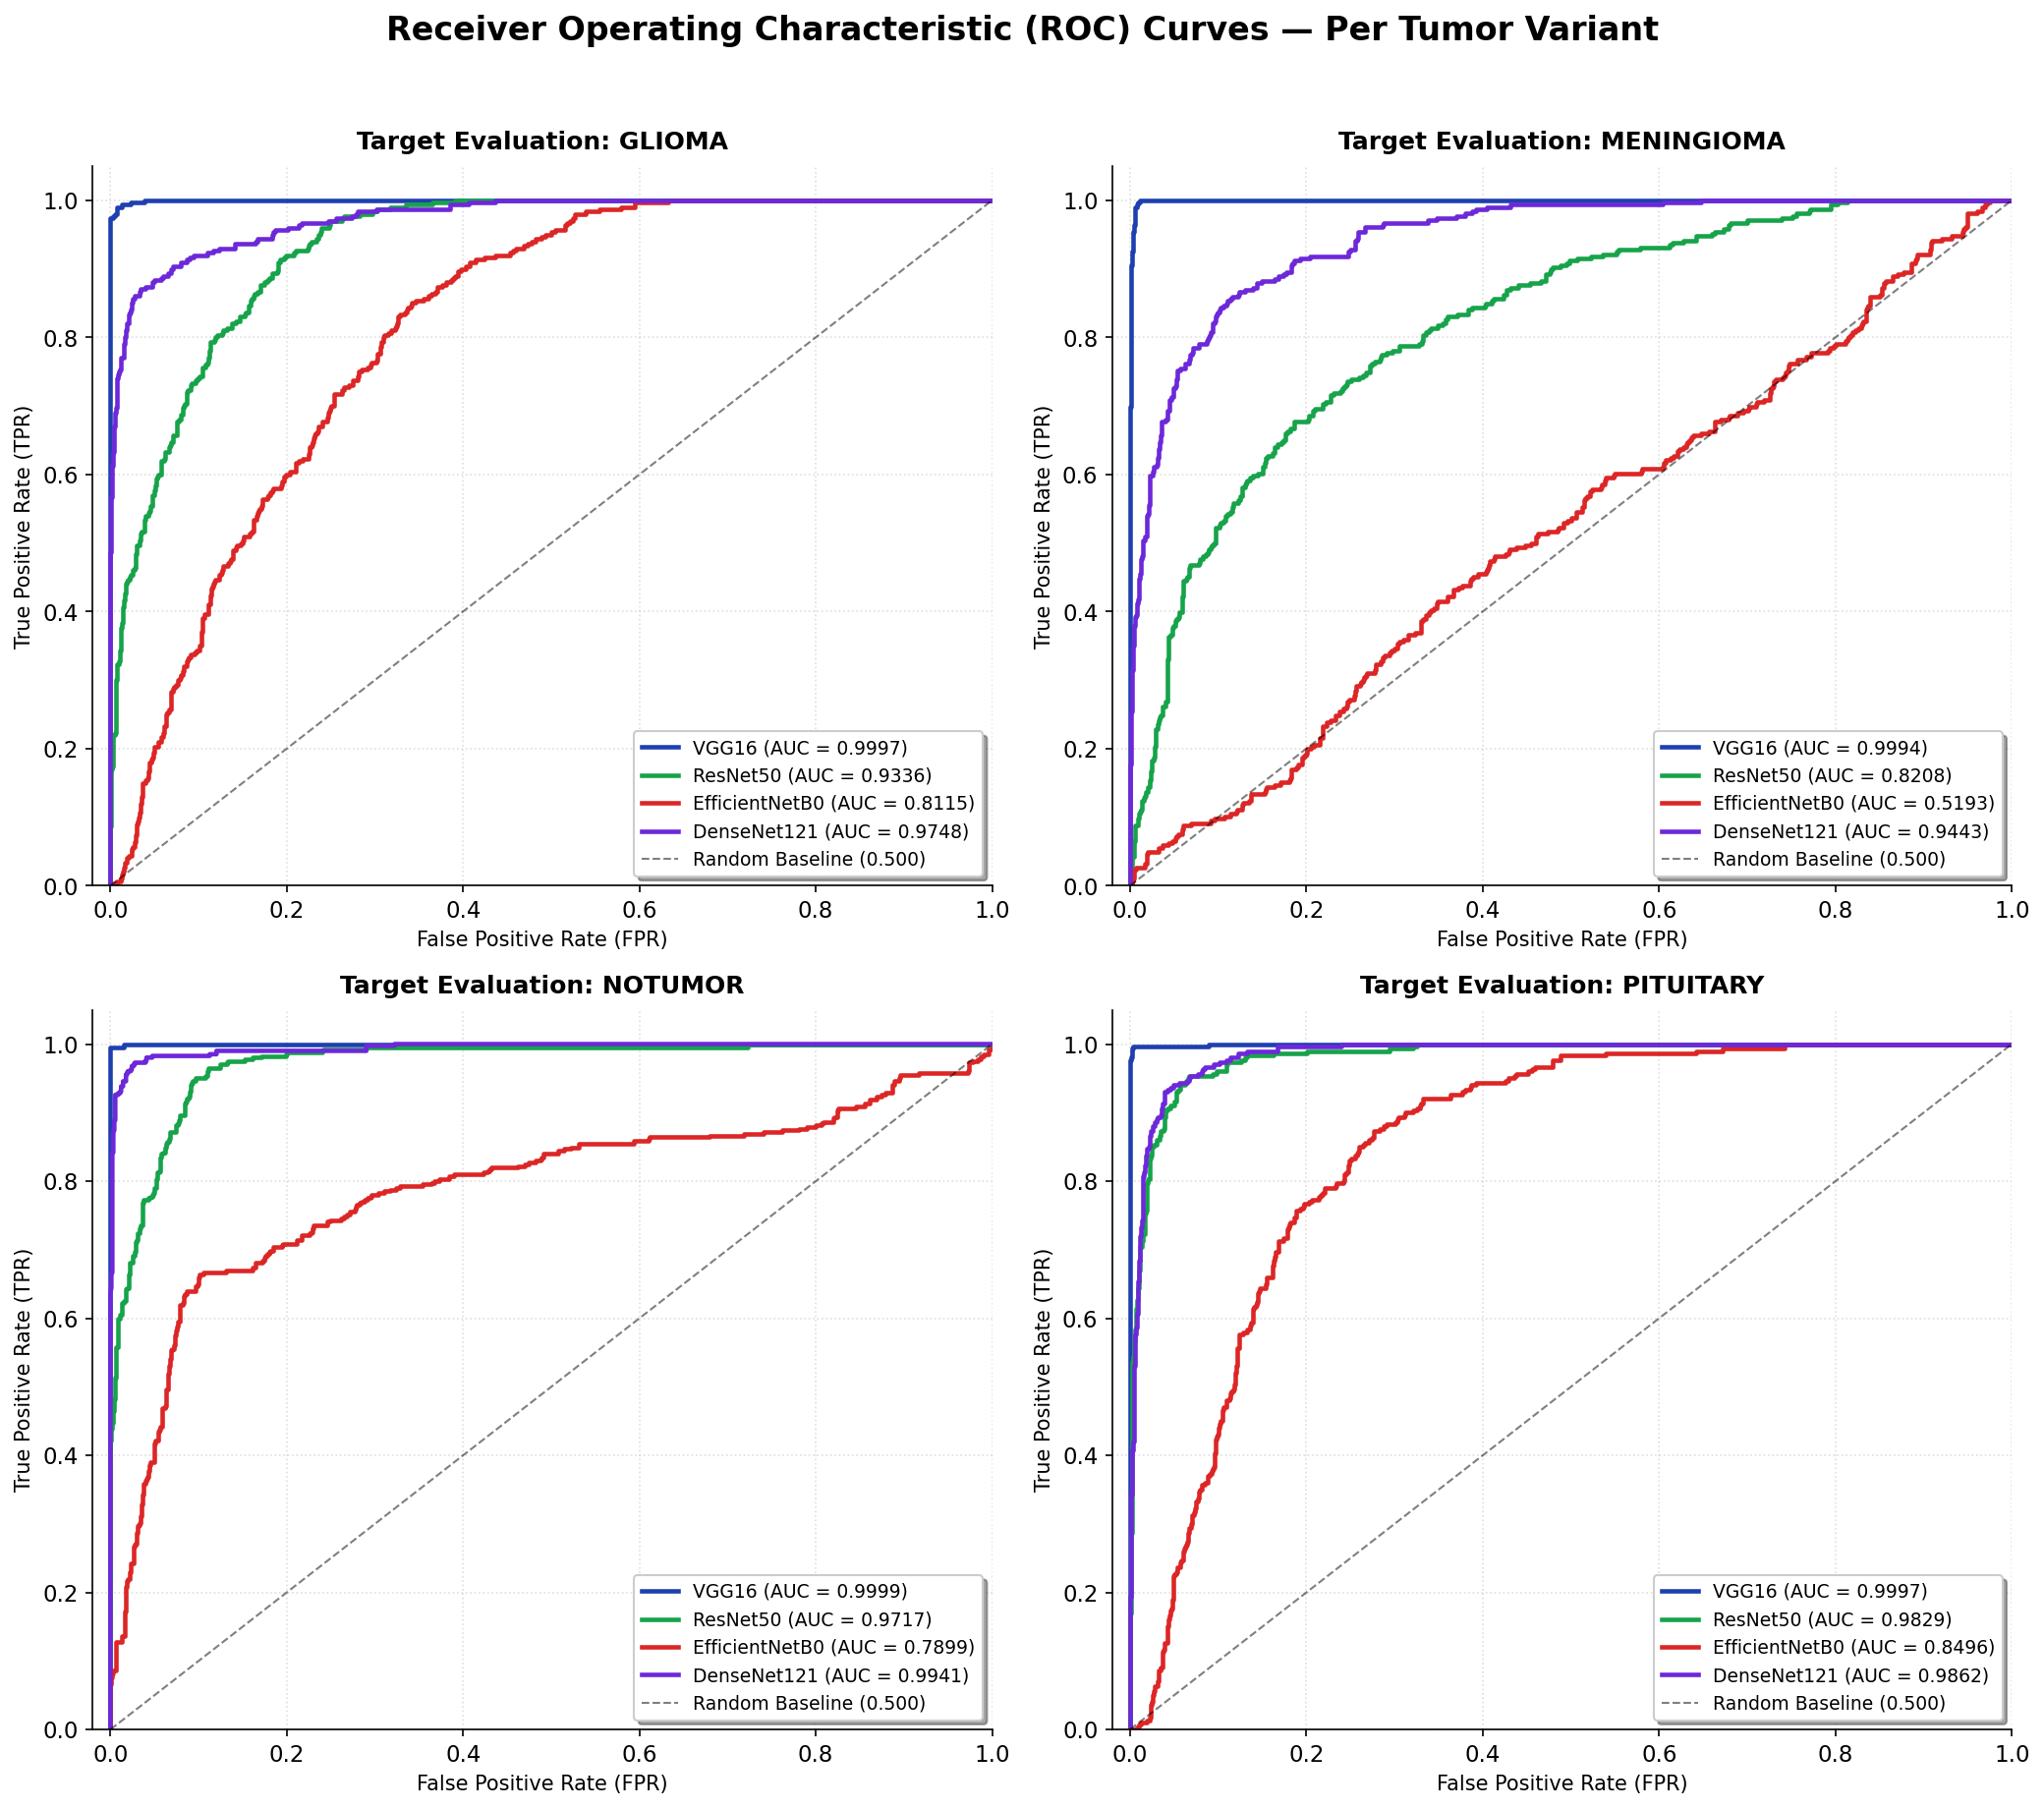

✅ Saved: roc_curves.png (2x2 Uniform Layout)

══════════════════════════════════════════════════════════════════════════════════════════════
 📊                      FINAL DEEP LEARNING MODEL COMPARISON SUMMARY                      📊
══════════════════════════════════════════════════════════════════════════════════════════════
 │ Model Name         │   Accuracy   │  Precision   │    Recall    │   F1-Score   │ Latency (ms)  │
 ├────────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┤
 │ VGG16              │    0.9878    │    0.9878    │    0.9878    │    0.9878    │    645.70     │ 🌟 [BEST]
 │ ResNet50           │    0.7559    │    0.7469    │    0.7559    │    0.7427    │    185.55     │
 │ EfficientNetB0     │    0.4912    │    0.5290    │    0.4912    │    0.4912    │    549.86     │
 │ DenseNet121        │    0.7460    │    0.8096    │    0.7460    │    0.7192    │    191.33     │
═══════════════════════════════════════════════════════════════

In [10]:
# ============================================================
# 6. PLOT: METRICS BAR CHART
# ============================================================
def plot_metrics_comparison(all_results):
    metrics       = ['accuracy', 'precision', 'recall', 'f1']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Model Performance & Efficiency Comparison', fontsize=16, fontweight='bold', y=1.02)

    # --- Grouped bar chart ---
    x     = np.arange(len(metrics))
    width = 0.18 # Adjusted width to beautifully accommodate 4 models side-by-side

    for i, res in enumerate(all_results):
        values = [res[m] for m in metrics]
        bars   = axes[0].bar(x + i*width, values, width, label=res['model_name'],
                             color=COLORS[i], alpha=0.9, edgecolor='white', linewidth=0.8)

        # Value labels on top of each bar
        for bar, v in zip(bars, values):
            axes[0].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.008,
                         f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='medium')

    axes[0].set_xticks(x + (width * (len(all_results)-1) / 2))
    axes[0].set_xticklabels(metric_labels, fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Score Metrics', fontsize=11, fontweight='bold')
    axes[0].set_ylim([0, 1.15])
    axes[0].legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', shadow=True)
    axes[0].set_title('Global Performance Metrics (Higher is Better)', fontsize=12, fontweight='bold', pad=10)
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)

    # --- Inference time ---
    times = [res['inference_time'] for res in all_results]
    names = [res['model_name']     for res in all_results]

    # FIXED: Changed width=0.4f to width=0.4 to prevent literal syntax error
    bars2 = axes[1].bar(names, times, color=COLORS[:len(all_results)], alpha=0.9, edgecolor='white', width=0.4)
    for bar, t in zip(bars2, times):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + (max(times) * 0.01),
                     f'{t:.2f} ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[1].set_ylabel('Inference Time (ms per image)', fontsize=11, fontweight='bold')
    axes[1].set_title('Inference Latency Execution Speed (Lower is Better)', fontsize=12, fontweight='bold', pad=10)
    axes[1].set_ylim([0, max(times) * 1.25])
    axes[1].grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=180)
    plt.show()
    print("✅ Saved: metrics_comparison.png")

# ============================================================
# 7. PLOT: PER-CLASS F1 HEATMAP (Consolidated Matrix Layout)
# ============================================================
def plot_perclass_heatmap(all_results, class_names):
    # Dynamically build a uniform 2D matrix structure [Models x Classes]
    matrix_data = []
    model_names = []

    for res in all_results:
        model_names.append(res['model_name'])
        row = [res['per_class_f1'][c] for c in class_names]
        matrix_data.append(row)

    # Transforming into a scannable structure
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        matrix_data, annot=True, fmt='.4f', cmap='RdYlGn',
        xticklabels=class_names, yticklabels=model_names,
        ax=ax, vmin=0, vmax=1, linewidths=1.5,
        annot_kws={'size': 12, 'weight': 'bold'}, cbar=True
    )

    ax.set_title('Cross-Model Per-Class F1 Score Matrix Analysis', fontsize=14, fontweight='bold', pad=15)
    ax.tick_params(axis='x', rotation=15, labelsize=11)
    ax.tick_params(axis='y', rotation=0, labelsize=11)

    plt.tight_layout()
    plt.savefig('perclass_f1.png', bbox_inches='tight', dpi=180)
    plt.show()
    print("✅ Saved: perclass_f1.png (Consolidated Matrix View)")

# ============================================================
# 8. PLOT: ROC CURVES (Optimized Balanced 2x2 Grid Layout)
# ============================================================
def plot_roc_curves(all_results, class_names):
    n_classes = len(class_names)

    # 2x2 multi-axis subplot arrangement ensures compatibility up to 4 distinct classes
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Receiver Operating Characteristic (ROC) Curves — Per Tumor Variant', fontsize=16, fontweight='bold', y=1.02)

    axes_flat = axes.flatten()

    for ci, cname in enumerate(class_names):
        ax = axes_flat[ci]
        for ri, res in enumerate(all_results):
            y_bin   = (res['y_true'] == ci).astype(int)
            y_score = res['preds_probs'][:, ci]
            fpr, tpr, _ = roc_curve(y_bin, y_score)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2.2, color=COLORS[ri],
                    label=f"{res['model_name']} (AUC = {roc_auc:.4f})")

        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Baseline (0.500)')
        ax.set_xlim([-0.02, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate (FPR)', fontsize=10, fontweight='medium')
        ax.set_ylabel('True Positive Rate (TPR)', fontsize=10, fontweight='medium')
        ax.set_title(f'Target Evaluation: {cname.upper()}', fontsize=12, fontweight='bold', pad=8)
        ax.legend(fontsize=9, loc='lower right', frameon=True, shadow=True)
        ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight', dpi=180)
    plt.show()
    print("✅ Saved: roc_curves.png (2x2 Uniform Layout)")

# ============================================================
# 10. FINAL SUMMARY TABLE (Unicode Enhanced Report Generation)
# ============================================================
def print_summary_table(all_results):
    print(f"\n" + "═"*94)
    print(f" 📊 { 'FINAL DEEP LEARNING MODEL COMPARISON SUMMARY' :^86} 📊")
    print("═"*94)

    header = f" │ {'Model Name':<18} │ {'Accuracy':^12} │ {'Precision':^12} │ {'Recall':^12} │ {'F1-Score':^12} │ {'Latency (ms)':^13} │"
    print(header)
    print(f" ├{'─'*20}┼{'─'*14}┼{'─'*14}┼{'─'*14}┼{'─'*14}┼{'─'*15}┤")

    best_f1 = max(r['f1'] for r in all_results)
    for res in all_results:
        marker = " 🌟 [BEST]" if res['f1'] == best_f1 else ""
        print(
            f" │ {res['model_name']:<18} │ "
            f"{res['accuracy']:^12.4f} │ "
            f"{res['precision']:^12.4f} │ "
            f"{res['recall']:^12.4f} │ "
            f"{res['f1']:^12.4f} │ "
            f"{res['inference_time']:^13.2f} │"
            f"{marker}"
        )
    print("═"*94)

    best = max(all_results, key=lambda r: r['f1'])
    print(f"\n🏆 CHAMPION SELECTION MODEL EVALUATION:")
    print(f" ├─ Selected Architecture : {best['model_name'].upper()}")
    print(f" ├─ Target Accuracy       : {best['accuracy']:.4f}  ({best['accuracy']:.2%})")
    print(f" ├─ Macro F1-Score        : {best['f1']:.4f}  ({best['f1']:.2%})")
    print(f" └─ Prediction Latency    : {best['inference_time']:.2f} ms / input vector frame\n")
    return best

# ============================================================
# 11. SAVE ALL FIGURES TO ONE PDF
# ============================================================
def save_all_to_pdf(filename='model_comparison_report.pdf'):
    images = [
        'confusion_matrices.png',
        'metrics_comparison.png',
        'perclass_f1.png',
        'roc_curves.png',
        'misclassified.png',
    ]
    with PdfPages(filename) as pdf:
        for img_path in images:
            try:
                img = plt.imread(img_path)
                fig, ax = plt.subplots(figsize=(14, 9))
                ax.imshow(img)
                ax.axis('off')
                pdf.savefig(fig, bbox_inches='tight', dpi=200)
                plt.close(fig)
            except FileNotFoundError:
                pass
    print(f"📂 Report Generation Successful: {filename}")

# ============================================================
# 12. MAIN — RUN EVERYTHING
# ============================================================
def compare_all_models(models_list, model_names_list, test_generator, class_names):
    print("\n" + "█"*75)
    print(" 🧠  SYSTEM PIPELINE DIAGNOSTIC: INTER-MODEL BENCHMARKING OPERATIONS")
    print("█"*75)

    # Step 1: Evaluate all models sequentially
    all_results = []
    for model, name in zip(models_list, model_names_list):
        res = evaluate_single_model(model, test_generator, name, class_names)
        all_results.append(res)

    # Step 2: Graphics Rendering Engine Tasks
    print("\n🎬 Initializing High-Resolution Plot Rendering Pipelines...\n")
    plot_confusion_matrices(all_results, class_names)
    plot_metrics_comparison(all_results)
    plot_perclass_heatmap(all_results, class_names)
    plot_roc_curves(all_results, class_names)

    # Step 3: Performance Parsing & Metrics Tables
    best = print_summary_table(all_results)
    best_res = next(r for r in all_results if r['model_name'] == best['model_name'])

    # Error Inspection Phase
    try:
        plot_misclassified(best_res, test_generator, class_names, n=12)
    except NameError:
        print("⚠️ Note: plot_misclassified function was not captured in this block script execution.")

    # Step 4: Display Standard Raw Report for Context Validation
    print(f"\n📝 Detailed Target Classification Matrix — {best['model_name'].upper()}")
    print("═"*70)
    print(best_res['classification_report'])

    # Step 5: Export Compressed Presentation Vector File
    save_all_to_pdf('model_comparison_report2.pdf')

    print("\n🎯 PIPELINE PERFORMANCE COMPARISON COMPLETE! ALL TARGET OBJECTS EXPORTED.")
    return all_results

# ============================================================
# RUN THE ENGINE
# ============================================================
all_results = compare_all_models(models_list, model_names_list, test_generator, class_names)